In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
df = pd.read_csv("C:/Users/MANH HO KIEN/Downloads/Customer_Behaviour.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [4]:
df.isnull().sum()
df = df.dropna()

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [7]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [11]:
print(df.dtypes)

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


In [12]:
X = df[["Gender","Age","EstimatedSalary"]]
y = df["Purchased"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.875


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90        51
           1       0.85      0.79      0.82        29

    accuracy                           0.88        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.87      0.88      0.87        80



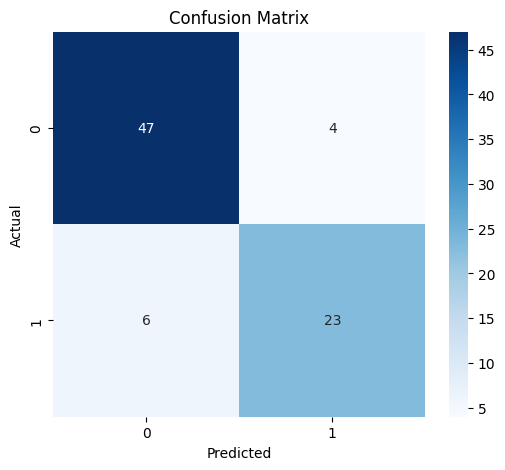

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

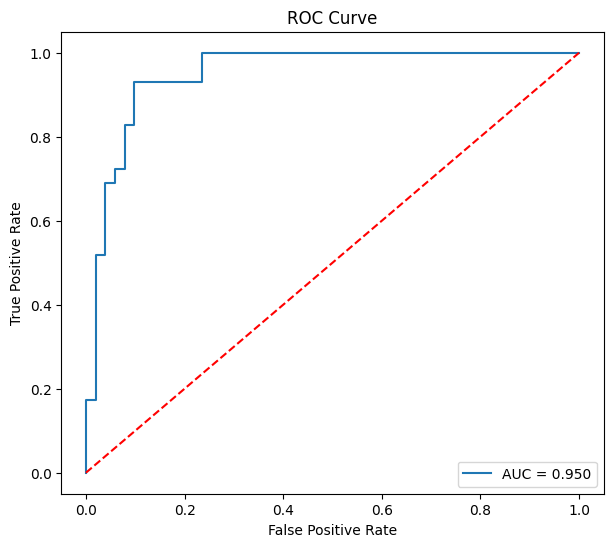

In [20]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="AUC = %.3f" % auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [21]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head(20))

     Actual  Predicted
331       1          1
92        0          0
1         0          0
234       0          1
136       0          0
356       1          1
122       0          0
223       1          1
64        0          1
398       0          0
257       0          0
344       1          1
16        1          1
298       0          1
97        1          0
89        0          0
152       0          0
209       0          1
322       0          0
227       1          1


In [22]:
prob = pd.DataFrame(
    model.predict_proba(X_test),
    columns=["Class 0 Probability", "Class 1 Probability"]
)

print(prob.head())

   Class 0 Probability  Class 1 Probability
0             0.037882             0.962118
1             0.966564             0.033436
2             0.881268             0.118732
3             0.329926             0.670074
4             0.980298             0.019702


In [23]:
mean_table = pd.DataFrame(
    model.theta_,
    columns=X.columns,
    index=["Class 0","Class 1"]
)

print(mean_table)

           Gender        Age  EstimatedSalary
Class 0  0.470874  32.252427     60233.009709
Class 1  0.438596  46.017544     89877.192982
